## Project skin burn classification using EfficientNetB3

In [2]:
import tensorflow as tf
import os
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler, CSVLogger
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import logging
from sklearn.preprocessing import label_binarize

In [5]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

# GPU Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"Using GPU: {gpus[0]}")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("No GPU found, using CPU")
tf.keras.backend.clear_session()
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Constants
IMG_HEIGHT = 240
IMG_WIDTH = 240
NUM_CLASSES = 4  # 4 classes including No Skin burn
EPOCHS_INITIAL = 10
EPOCHS_FINE_TUNE = 15
BATCH_SIZE = 32
DATA_DIR = '/kaggle/input/data-set/Skin burn Dataset'
CLASS_NAMES = ['No Skin burn (Normal Skin)', '1st degree', '2nd degree', '3rd degree']  # Match folder names

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [6]:
# Data Augmentation for improved generalization
def preprocess_image(image, label):
    image = tf.image.resize_with_pad(image, IMG_HEIGHT, IMG_WIDTH)
    # Apply augmentation only during training
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

def create_dataset_from_directory(data_dir, subset, batch_size):
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset=subset,
        seed=42,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        label_mode='categorical',
        class_names=['No Skin burn (Normal Skin)', '1st degree', '2nd degree', '3rd degree'],  # Match folder names
        shuffle=True
    )
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.prefetch(tf.data.AUTOTUNE)

train_dataset_base = create_dataset_from_directory(DATA_DIR, 'training', BATCH_SIZE)
val_test_dataset = create_dataset_from_directory(DATA_DIR, 'validation', BATCH_SIZE)

# Update sample counts to include No Skin burn
total_train_samples = 35655 + 2480  # 35655 (original) + 80% of 3100 (No Skin burn)
total_val_test_samples = 8913 + 620  # 8913 (original) + 20% of 3100 (No Skin burn)
val_samples = total_val_test_samples // 2
test_samples = total_val_test_samples - val_samples
train_steps = max(1, total_train_samples // BATCH_SIZE)
val_steps = max(1, val_samples // BATCH_SIZE)
test_steps = max(1, test_samples // BATCH_SIZE)

train_dataset = train_dataset_base.repeat()
val_dataset = val_test_dataset.take(val_steps).repeat()
test_dataset = val_test_dataset.skip(val_steps)

Found 47683 files belonging to 4 classes.
Using 38147 files for training.
Found 47683 files belonging to 4 classes.
Using 9536 files for validation.


In [7]:
# Class Weights
labels = [0] * 3100 + [1] * 18181 + [2] * 17093 + [3] * 9294  # No Skin burn: 3100 images
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 3.844193548387097, 1: 0.6554644959023156, 2: 0.6971859825659626, 3: 1.2822250914568538}


In [8]:
# Learning rate schedules
def lr_schedule_initial(epoch, initial_lr=0.001):
    if epoch < 5: return initial_lr
    return float(initial_lr * np.exp(-0.2 * (epoch - 5)))

def lr_schedule_fine_tune(epoch, initial_lr=0.00005):
    if epoch < 5: return initial_lr
    return float(initial_lr * np.exp(-0.2 * (epoch - 5)))

In [9]:
# Build and train model
def build_and_train_model():
    tf.keras.backend.clear_session()
    base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.6),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')  # Updated to 4 classes
    ])
    
    from tensorflow.keras.mixed_precision import set_global_policy
    set_global_policy('mixed_float16')
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    
    callbacks_initial = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint("best_model_initial.keras", monitor='val_accuracy', save_best_only=True, mode='max'),
        LearningRateScheduler(lr_schedule_initial),
        CSVLogger('training_log.csv', append=True)
    ]
    
    print("Phase 1: Training with frozen base model...")
    history_initial = model.fit(
        train_dataset, steps_per_epoch=train_steps, epochs=EPOCHS_INITIAL,
        validation_data=val_dataset, validation_steps=val_steps,
        callbacks=callbacks_initial, verbose=1, class_weight=class_weight_dict
    )
    
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005, clipnorm=1.0, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    
    callbacks_fine_tune = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint("best_model_finetuned.keras", monitor='val_accuracy', save_best_only=True, mode='max'),
        LearningRateScheduler(lr_schedule_fine_tune),
        CSVLogger('training_log.csv', append=True)
    ]
    
    print("\nPhase 2: Fine-tuning with 30 unfrozen layers...")
    history_fine_tune = model.fit(
        train_dataset, steps_per_epoch=train_steps, epochs=EPOCHS_FINE_TUNE,
        validation_data=val_dataset, validation_steps=val_steps,
        callbacks=callbacks_fine_tune, verbose=1, class_weight=class_weight_dict
    )
    
    return model, history_initial, history_fine_tune

print("Training the model...")
model, history_initial, history_fine_tune = build_and_train_model()

Training the model...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Training with frozen base model...
Epoch 1/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 163s 104ms/step - accuracy: 0.6776 - auc: 0.8850 - loss: 1.8756 - val_accuracy: 0.7703 - val_auc: 0.9508 - val_loss: 0.7290 - learning_rate: 0.0010
Epoch 2/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 131s 110ms/step - accuracy: 0.7397 - auc: 0.9308 - loss: 0.7153 - val_accuracy: 0.7798 - val_auc: 0.9519 - val_loss: 0.6971 - learning_rate: 0.0010
Epoch 3/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 113s 95ms/step - accuracy: 0.7450 - auc: 0.9347 - loss: 0.6806 - val_accuracy: 0.7796 - val_auc: 0.9509 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 4/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 114s 96ms/step - accuracy: 0.7461 - auc: 0.9338 - loss: 0.6814 - val_accuracy: 0.7878 - val_auc: 0.9563 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 5/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 114s 96ms/step - accuracy: 0.7479 - auc: 0.9362 - loss: 0.6650 - val_accuracy: 0.79

In [10]:
# Evaluate
logger.info("\nEvaluating on validation set...")
val_metrics = model.evaluate(val_dataset, steps=val_steps, return_dict=True)
logger.info(f"Validation Accuracy: {val_metrics['accuracy']:.4f}, Validation Loss: {val_metrics['loss']:.4f}, Validation AUC: {val_metrics['auc']:.4f}")

logger.info("\nEvaluating on test set...")
test_metrics = model.evaluate(test_dataset, steps=test_steps, return_dict=True)
logger.info(f"Test Accuracy: {test_metrics['accuracy']:.4f}, Test Loss: {test_metrics['loss']:.4f}, Test AUC: {test_metrics['auc']:.4f}")

148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.9541 - auc: 0.9951 - loss: 0.1593
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.9574 - auc: 0.9954 - loss: 0.1512


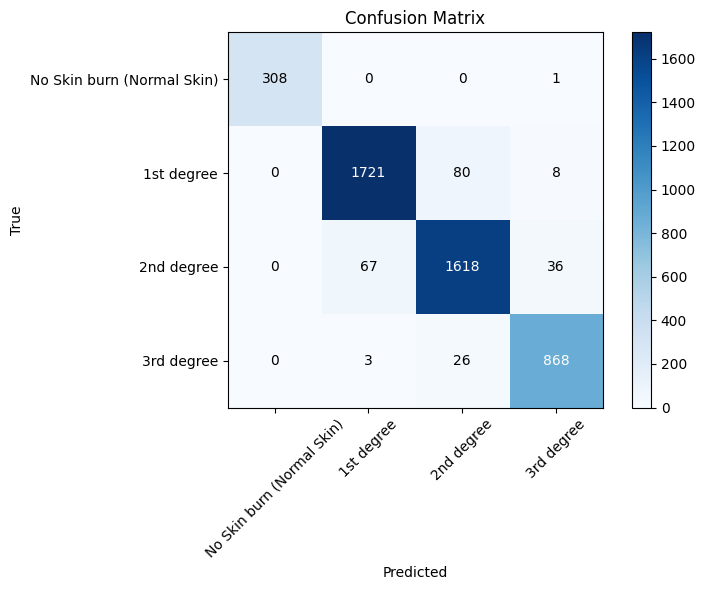

In [11]:
# Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

logger.info("Generating Confusion Matrix...")
y_true, y_pred = [], []
for images, labels in test_dataset.take(test_steps):
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
logger.info(f"Confusion Matrix:\n{cm}")

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()
logger.info("Confusion matrix saved as '/kaggle/working/confusion_matrix.png'")

In [12]:
# Classification Report
from sklearn.metrics import classification_report
import numpy as np

logger.info("Generating Classification Report...")
try:
    y_true, y_pred = [], []
    for images, labels in test_dataset.take(test_steps):
        predictions = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))
    
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
    logger.info("\nClassification Report:\n" + report)
    print("\nClassification Report:\n" + report)
    
except Exception as e:
    logger.error(f"Classification report generation failed: {str(e)}", exc_info=True)
    print(f"Error: {str(e)}")


Classification Report:
                            precision    recall  f1-score   support

No Skin burn (Normal Skin)       1.00      1.00      1.00       309
                1st degree       0.97      0.95      0.96      1816
                2nd degree       0.93      0.95      0.94      1729
                3rd degree       0.95      0.97      0.96       882

                  accuracy                           0.95      4736
                 macro avg       0.96      0.96      0.96      4736
              weighted avg       0.95      0.95      0.95      4736



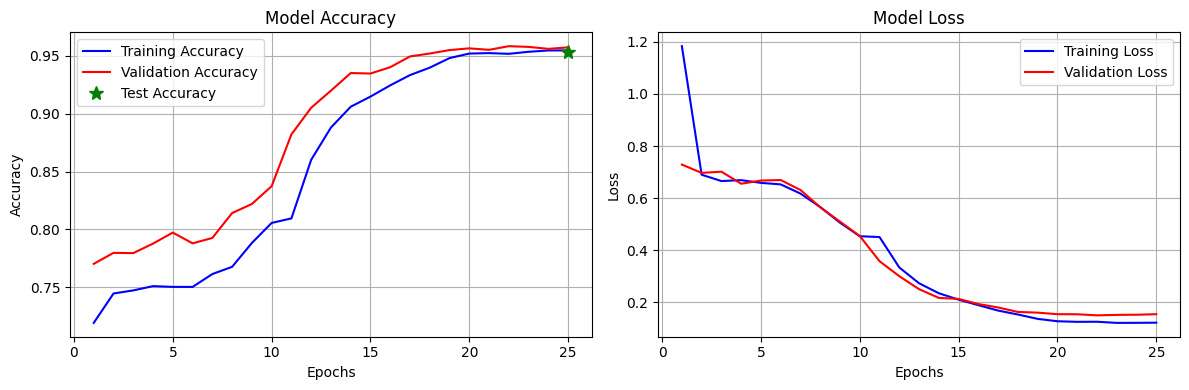

In [13]:
# Training History
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

def get_test_accuracy(model, dataset):
    logger.info("Evaluating model to get test accuracy...")
    y_true, y_pred = [], []
    for images, labels in dataset.take(test_steps):
        predictions = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))
    return accuracy_score(y_true, y_pred)

logger.info("Plotting Training History...")
try:
    test_accuracy = get_test_accuracy(model, test_dataset)
    logger.info(f"Test Accuracy: {test_accuracy:.4f}")

    acc = history_initial.history['accuracy'] + history_fine_tune.history['accuracy']
    val_acc = history_initial.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
    loss = history_initial.history['loss'] + history_fine_tune.history['loss']
    val_loss = history_initial.history['val_loss'] + history_fine_tune.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.plot(epochs[-1], test_accuracy, 'g*', label='Test Accuracy', markersize=10)
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png')
    plt.show()
    logger.info("Training curves saved as '/kaggle/working/training_curves.png'")

except Exception as e:
    logger.error(f"Visualization failed: {str(e)}", exc_info=True)
    print(f"Error: {str(e)}")

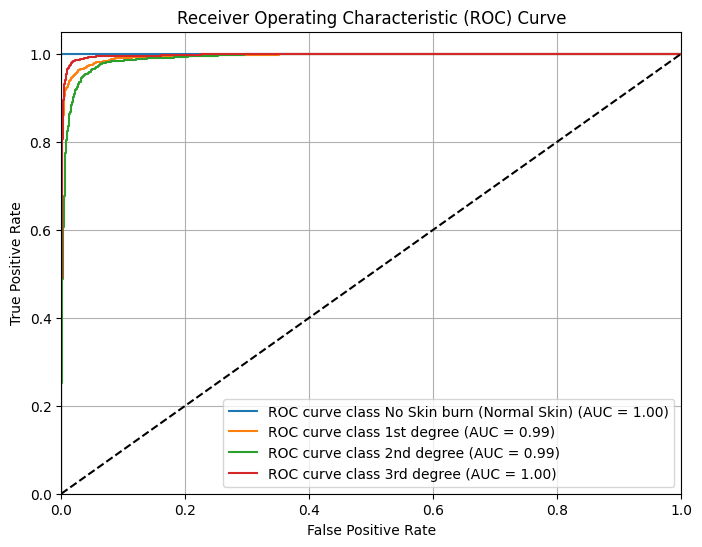

In [14]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

logger.info("Generating ROC Curve...")
try:
    y_true, y_score = [], []
    for images, labels in test_dataset.take(test_steps):
        probabilities = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_score.extend(probabilities)

    y_true = np.array(y_true)
    y_score = np.array(y_score)
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    plt.figure(figsize=(8, 6))
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'ROC curve class {CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig('/kaggle/working/roc_curve.png')
    plt.show()
    logger.info("ROC curve saved as '/kaggle/working/roc_curve.png'")

except Exception as e:
    logger.error(f"ROC calculation failed: {str(e)}", exc_info=True)
    print(f"Error: {str(e)}")

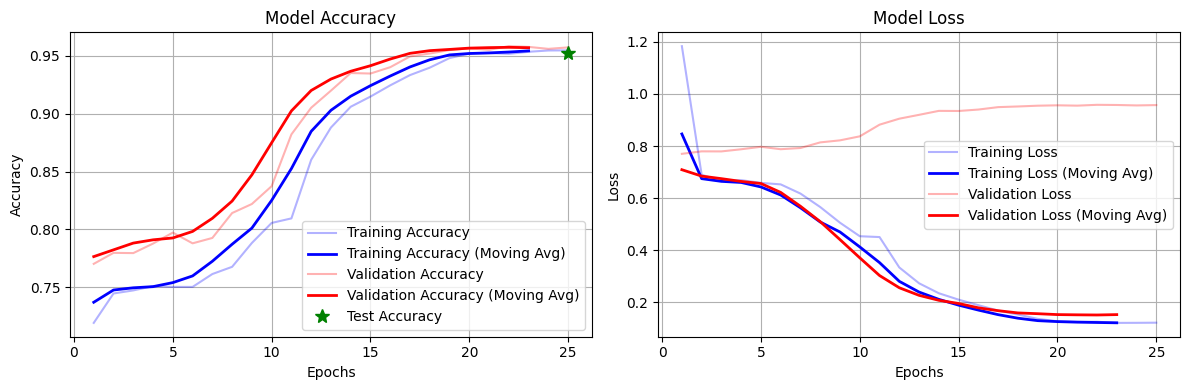

In [15]:
# Training History with Moving Average
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

def get_test_accuracy(model, dataset):
    logger.info("Evaluating model to get test accuracy...")
    y_true, y_pred = [], []
    for images, labels in dataset.take(test_steps):
        predictions = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))
    return accuracy_score(y_true, y_pred)

def moving_average(data, window_size=3):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

logger.info("Plotting Training History with Moving Average...")
try:
    test_accuracy = get_test_accuracy(model, test_dataset)
    logger.info(f"Test Accuracy: {test_accuracy:.4f}")

    acc = history_initial.history['accuracy'] + history_fine_tune.history['accuracy']
    val_acc = history_initial.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
    loss = history_initial.history['loss'] + history_fine_tune.history['loss']
    val_loss = history_initial.history['val_loss'] + history_fine_tune.history['val_loss']

    epochs = range(1, len(acc) + 1)
    acc_ma = moving_average(acc, 3)
    val_acc_ma = moving_average(val_acc, 3)
    loss_ma = moving_average(loss, 3)
    val_loss_ma = moving_average(val_loss, 3)
    ma_epochs = range(1, len(acc_ma) + 1)

    plt.figure(figsize=(12, 4))

    # Plot accuracy with moving average
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy', alpha=0.3)
    plt.plot(ma_epochs, acc_ma, 'b-', label='Training Accuracy (Moving Avg)', linewidth=2)
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', alpha=0.3)
    plt.plot(ma_epochs, val_acc_ma, 'r-', label='Validation Accuracy (Moving Avg)', linewidth=2)
    plt.plot(epochs[-1], test_accuracy, 'g*', label='Test Accuracy', markersize=10)
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss with moving average
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss', alpha=0.3)
    plt.plot(ma_epochs, loss_ma, 'b-', label='Training Loss (Moving Avg)', linewidth=2)
    plt.plot(epochs, val_acc, 'r-', label='Validation Loss', alpha=0.3)
    plt.plot(ma_epochs, val_loss_ma, 'r-', label='Validation Loss (Moving Avg)', linewidth=2)
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves_ma.png')
    plt.show()
    logger.info("Training curves with moving average saved as '/kaggle/working/training_curves_ma.png'")

except Exception as e:
    logger.error(f"Visualization failed: {str(e)}", exc_info=True)
    print(f"Error: {str(e)}")

In [16]:
# Optimized TFLite conversion
def representative_dataset():
    for images, _ in train_dataset.take(100):
        images = tf.cast(images, tf.float32)  # Ensure data type
        yield [images]

logger.info("\nConverting to TFLite with Full Integer Quantization...")
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.int8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    converter.representative_dataset = representative_dataset
    converter.experimental_new_converter = True
    # Specify static input shape to fix dynamic tensor warning
    converter.input_shapes = [(1, 240, 240, 3)]
    # Provide quantization parameters to fix statistics warning
    converter.inference_input_quantization = {'scale': 1.0 / 255.0, 'zero_point': 0}
    
    # Convert the model
    tflite_model = converter.convert()
    
    # Save the model
    output_path = '/kaggle/working/EfficientNetB3_skin_burn_model.tflite'
    with open(output_path, 'wb') as f:
        f.write(tflite_model)
    logger.info(f"Quantized TFLite model saved successfully at: {output_path}")
    print(f"TFLite model saved at: {output_path}")
    
except Exception as e:
    logger.error(f"Error during TFLite conversion or saving: {e}")
    print(f"Error: {e}")
    raise

Saved artifact at '/tmp/tmpc1lypwm9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 240, 240, 3), dtype=tf.float32, name='keras_tensor_385')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134502749251264: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134502749248448: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134502754313216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134502754315328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134502754311808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134502754304592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134502754318672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134502749322080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134502749308000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134502749315920: TensorSpec(shape=(), dtype=tf.resource, name=

/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/convert.py:983: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model saved at: /kaggle/working/EfficientNetB3_skin_burn_model.tflite



Image: dry_5a510955ceb3efb852fa_jpg.rf.998805eef49e7598e27417a604d7b9b0.jpg (Class: No Skin burn (Normal Skin))
Predicted Class: No Skin burn (Normal Skin)
Probabilities: [0.99609375, 0.0, 0.0, 0.0]

Image: normal_b886f9300e4aa7717bda_jpg.rf.f020763590c72c395ec18873f54dea8e.jpg (Class: No Skin burn (Normal Skin))
Predicted Class: No Skin burn (Normal Skin)
Probabilities: [0.99609375, 0.0, 0.0, 0.0]

Image: oily_7a071fda3e1e2d3ec0c7_jpg.rf.ff89a078846d0108b39612f845e0c172.jpg (Class: No Skin burn (Normal Skin))
Predicted Class: No Skin burn (Normal Skin)
Probabilities: [0.99609375, 0.0, 0.0, 0.0]

Image: oily_b3104f9f3ebbf005e811_jpg.rf.d42df8af203340ee243330fddf97724f.jpg (Class: No Skin burn (Normal Skin))
Predicted Class: No Skin burn (Normal Skin)
Probabilities: [0.99609375, 0.0, 0.0, 0.0]

Image: normal_d68e84abbd43cce00a01_jpg.rf.301810d7c286ed741912ac70e5ec1683.jpg (Class: No Skin burn (Normal Skin))
Predicted Class: No Skin burn (Normal Skin)
Probabilities: [0.99609375, 0.0, 0.

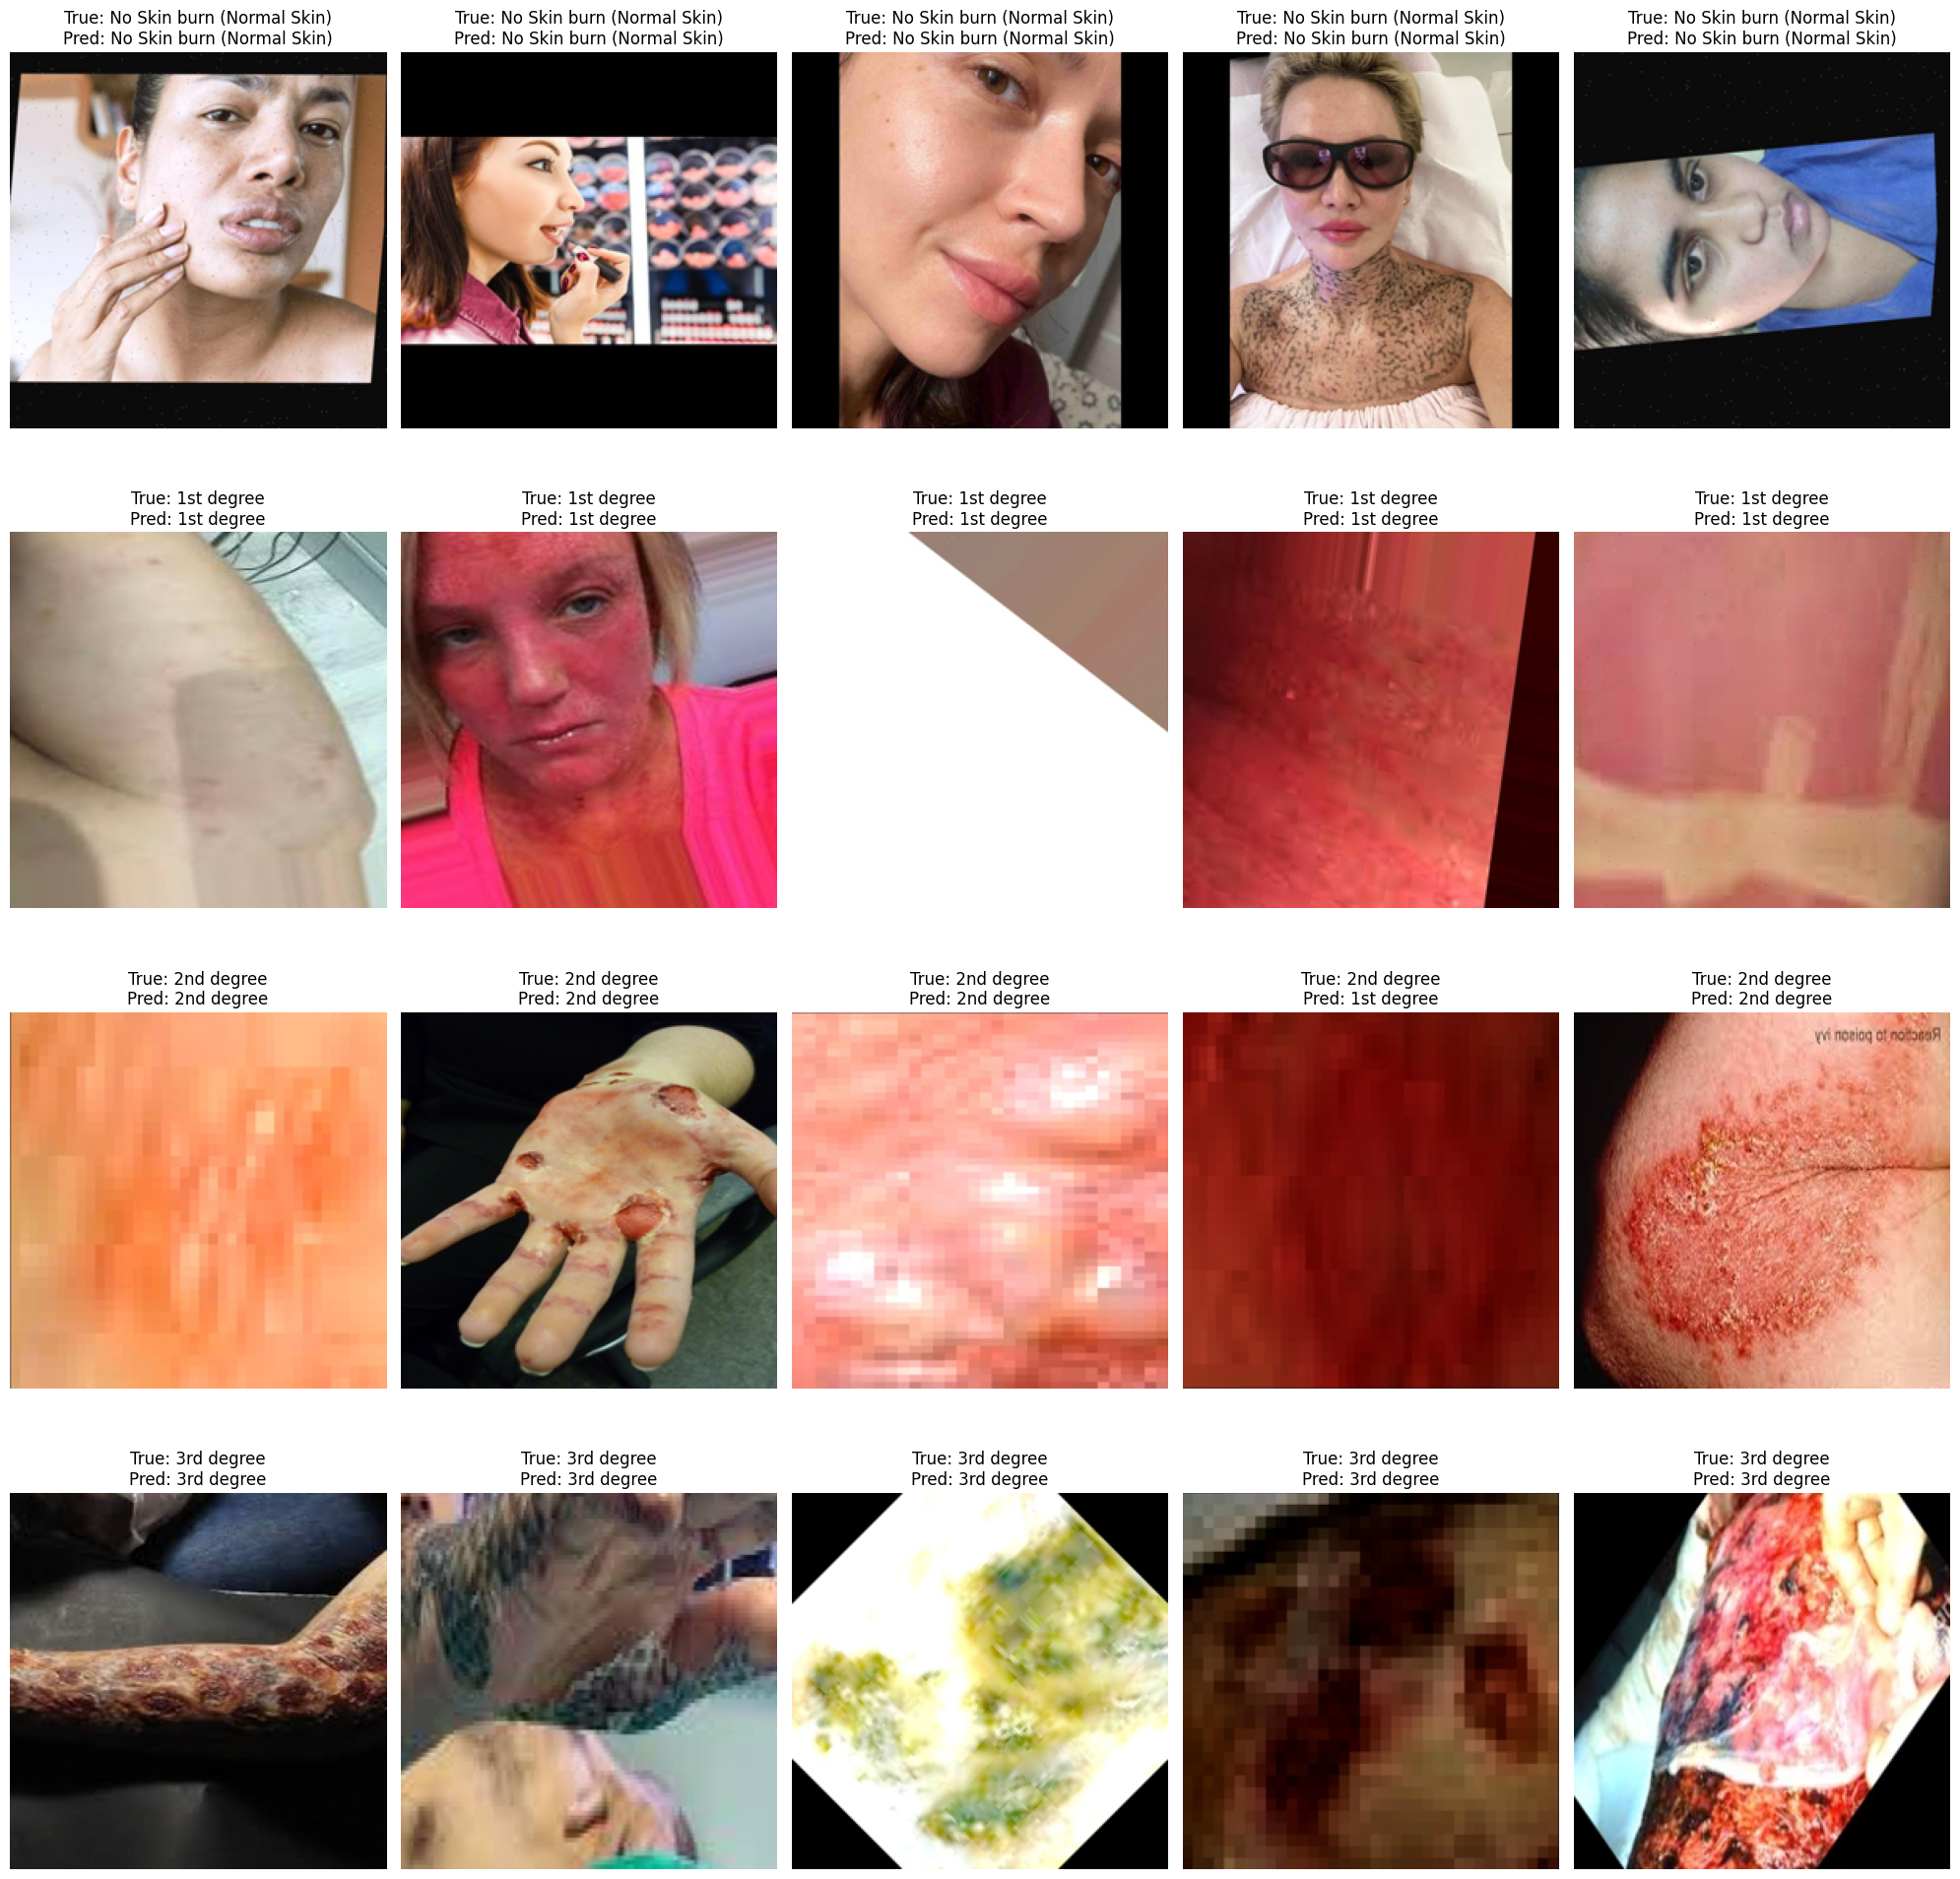

In [18]:
# Test 5 Random Images per Class with TFLite Model
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

logger.info("Testing TFLite model on 5 random images from each class...")

# Ensure constants are defined
try:
    DATA_DIR
    CLASS_NAMES
    IMG_HEIGHT
    IMG_WIDTH
except NameError:
    raise ValueError("Required constants (DATA_DIR, CLASS_NAMES, IMG_HEIGHT, IMG_WIDTH) are not defined. Ensure previous cells are executed.")

# Load the TFLite model
tflite_model_path = '/kaggle/working/EfficientNetB3_skin_burn_model.tflite'
try:
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    logger.info(f"TFLite model loaded successfully from {tflite_model_path}")
except Exception as e:
    logger.error(f"Failed to load TFLite model: {str(e)}")
    raise

# Function to preprocess a single image for TFLite
def preprocess_single_image_tflite(image_path):
    image = Image.open(image_path).convert('RGB')
    image = image.resize((IMG_WIDTH, IMG_HEIGHT))
    image_array = np.array(image, dtype=np.float32)
    image_array = tf.keras.applications.efficientnet.preprocess_input(image_array)
    
    # Quantize to INT8
    input_scale = input_details[0]['quantization'][0]
    input_zero_point = input_details[0]['quantization'][1]
    if input_scale != 0:  # Avoid division by zero
        image_array = (image_array / input_scale) + input_zero_point
    image_array = np.clip(image_array, -128, 127).astype(np.int8)
    
    image_array = np.expand_dims(image_array, axis=0)
    return image_array, image

# Test 5 random images from each class
num_images_per_class = 5
plt.figure(figsize=(20, 20))  # Adjusted for 5 images per class
for i, class_name in enumerate(CLASS_NAMES):
    # Get the folder path for the class
    class_folder = os.path.join(DATA_DIR, class_name)
    if not os.path.exists(class_folder):
        logger.error(f"Class folder {class_folder} does not exist.")
        continue
    
    # Get all image files in the folder
    image_files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if len(image_files) < num_images_per_class:
        logger.warning(f"Not enough images in {class_folder}. Found {len(image_files)}.")
        continue
    
    # Select 5 random images
    random_images = random.sample(image_files, num_images_per_class)
    
    for j, random_image in enumerate(random_images):
        image_path = os.path.join(class_folder, random_image)
        
        # Preprocess the image
        try:
            image_array, original_image = preprocess_single_image_tflite(image_path)
        except Exception as e:
            logger.error(f"Error processing image {image_path}: {str(e)}")
            continue
        
        # Predict with TFLite
        try:
            interpreter.set_tensor(input_details[0]['index'], image_array)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_details[0]['index'])
            
            # Dequantize the output
            output_scale = output_details[0]['quantization'][0]
            output_zero_point = output_details[0]['quantization'][1]
            dequantized_output = (output_data.astype(np.float32) - output_zero_point) * output_scale
            
            predicted_class = CLASS_NAMES[np.argmax(dequantized_output[0])]
            probabilities = dequantized_output[0].tolist()
            
            # Log and print results
            logger.info(f"\nImage: {random_image} (Class: {class_name})")
            logger.info(f"Predicted Class: {predicted_class}")
            logger.info(f"Probabilities: {probabilities}")
            print(f"\nImage: {random_image} (Class: {class_name})")
            print(f"Predicted Class: {predicted_class}")
            print(f"Probabilities: {probabilities}")
            
            # Display the image
            plt.subplot(len(CLASS_NAMES), num_images_per_class, i * num_images_per_class + j + 1)
            plt.imshow(original_image)
            plt.title(f"True: {class_name}\nPred: {predicted_class}")
            plt.axis('off')
            
        except Exception as e:
            logger.error(f"Error predicting image {image_path}: {str(e)}")
            continue

plt.tight_layout()
plt.savefig('/kaggle/working/tflite_5_images_per_class.png')
plt.show()
logger.info("TFLite 5 images per class predictions saved as '/kaggle/working/tflite_5_images_per_class.png'")